# 5 : Clasification - Model Training & Evaluation

 ## - KNN : k-nearest neighbors Algorithm

**- Euclidean Distance = ((f11-f12)^2 + (f21-f22)^2))^0.5** 

- Data Preparation
- Choose k
- Compute Distance
- Identify neighbor
- Make Prediction

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
x=df.iloc[:,0:8]
y=df['Outcome']
print(x.shape)
print(y.shape)

(768, 8)
(768,)


In [6]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [8]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=15)
model.fit(x_train,y_train)
prediction=model.predict(x_test)
print(prediction)

# nn=KNeighborsClassifier(n_neighbors=15)
# model=nn.fit(x_train,y_train)

[1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1 0
 1 0 1 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0
 0 0 0 1 0 0]


In [10]:
diff=pd.DataFrame({"Actual":y_test,"Prediction":prediction})
diff

,Actual,Prediction
285,0,1
101,0,0
581,0,0
352,0,0
726,0,0
...,...,...
563,0,0
318,0,0
154,1,1
684,0,0


In [11]:
diff.to_csv("diabeted_data.csv")

In [13]:
diff.to_excel("diabetes_data.xlsx")

In [14]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,prediction)
print(cm)

[[89 10]
 [23 32]]


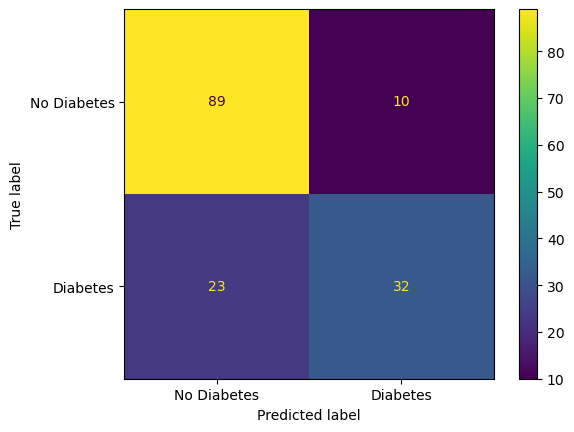

In [16]:
import matplotlib.pyplot as plt

from sklearn import metrics
cm_disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['No Diabetes','Diabetes'])
cm_disp.plot()
plt.show()

- 0-0 : True Negative
- 0-1 : False Positive
- 1-0 : False Negative
- 1-1 : True Positive

- No diabetes=0 & diabetes=1  in following example

In [18]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
print(TN,FP,FN,TP)

89 10 23 32


**1. Accuracy**=(TP+TN)/(TP+TN+FP+FN)

In [21]:
Accuracy=(TP+TN)/(TP+TN+FP+FN)
print("Accuracy Score : ",Accuracy)

Accuracy Score :  0.7857142857142857


In [ ]:
# Find that for which value of neighbor value of accuracy is accurate

from sklearn.neighbors import KNeighborsClassifier
acc=[]
for i in range(1,30):
    model=KNeighborsClassifier(n_neighbors=i)
    model.fit(x_train,y_train)
    prediction=model.predict(x_test)
    cm=confusion_matrix(y_test,prediction)
    TN=cm[0][0]
    FP=cm[0][1]
    FN=cm[1][0]
    TP=cm[1][1]
    Accuracy=(TP+TN)/(TP+TN+FP+FN)
    acc.append(Accuracy)
plt.plot(range(1,30),acc,marker='*')
plt.show()

In [26]:
from sklearn.metrics import accuracy_score
print("Accuracy Score = ",accuracy_score(y_test,prediction))

Accuracy Score =  0.7662337662337663


**2. Error Rate**= (1-Model Accuracy)
            =FN+FP/((FN+TN+TP+FP))

In [27]:
error_rate=1-((TP+TN)/(TP+TN+FP+FN))
print("Error Rate = ",error_rate)

Error Rate =  0.23376623376623373


**3. Sensitivity** = TP/(TP+FN)

In [30]:
print("sensitivity = ",(TP)/(TP+FN))

sensitivity =  0.5272727272727272


In [31]:
from sklearn.metrics import recall_score
print("Sensivity  = ",recall_score(y_test,prediction))

Sensivity  =  0.5272727272727272


**4. Specificity**= (TN)/(TN+FP)

In [32]:
specificity=(TN)/(TN+FP)
print("Specificity = ",specificity)

Specificity =  0.898989898989899


In [33]:
from sklearn.metrics import recall_score
print("Specificity  = ",recall_score(y_test,prediction,pos_label=0))

Specificity  =  0.898989898989899


**5. Precision Score** = (TP)/(TP+FP)

In [34]:
print("Precision Score  =  ",(TP)/(TP+FP))

Precision Score  =   0.7435897435897436


In [36]:
from sklearn.metrics import precision_score
print("Precison Score = ",precision_score(y_test,prediction))

Precison Score =  0.7435897435897436
